# Diagnostics

In **Cross-validation** scheme: the corresponding training set consists only of observations that occurred prior to the observation that forms the test set. Thus, no future observations can be used in constructing the forecast.

Note: since it is not possible to obtain a reliable forecast based on a small training set, the earliest observations are not considered as test sets.

The following figure illustrates the series of training and test sets, where the blue observations form the training sets, and the orange observations form the test sets:

![Time series cross-validation.](../assets/time_cross-validation.png){height=300}

The forecast accuracy is computed by averaging over the test sets. This procedure is sometimes known as “evaluation on a rolling forecasting origin” because the “origin” at which the forecast is based rolls forward in time.

## Cross-validation in Prophet

This cross validation procedure can be done automatically for a range of historical cutoffs using the `cross_validation` function. We specify the forecast horizon (`horizon`), and then optionally the size of the initial training period (`initial`) and the spacing between cutoff dates (`period`). By default, the initial training period is set to three times the horizon, and cutoffs are made every half a horizon.


This figure illustrates a simulated historical forecast on the Peyton Manning dataset, where the model was fit to an initial history of 5 years, and a forecast was made on a one year horizon.

![](../assets/initial_cutoff_horizon_forecast.png){height=400}

### Load the data

In [1]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [2]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)

# Prophet needs dates as datetime objects, not strings.
df["ds"] = pd.to_datetime(df["ds"])

df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


In [3]:
m = Prophet()
m.fit(df)

11:40:00 - cmdstanpy - INFO - Chain [1] start processing
11:40:00 - cmdstanpy - INFO - Chain [1] done processing


Here we do cross-validation:

In [4]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(
    model=m,
    initial='730 days',   # starting with 730 days of training data in the first cutoff
    horizon = '365 days', # assess prediction performance on a horizon of 365 days
    period='180 days',    # making predictions every 180 days (shift)
                          # On this 8 year time series, this corresponds to 11 total forecasts.
)
# Note: string for initial, period, and horizon should be in the format used by Pandas Timedelta,
# which accepts units of days or shorter

  0%|          | 0/11 [00:00<?, ?it/s]

11:40:00 - cmdstanpy - INFO - Chain [1] start processing
11:40:01 - cmdstanpy - INFO - Chain [1] done processing
11:40:01 - cmdstanpy - INFO - Chain [1] start processing
11:40:01 - cmdstanpy - INFO - Chain [1] done processing
11:40:01 - cmdstanpy - INFO - Chain [1] start processing
11:40:01 - cmdstanpy - INFO - Chain [1] done processing
11:40:01 - cmdstanpy - INFO - Chain [1] start processing
11:40:02 - cmdstanpy - INFO - Chain [1] done processing
11:40:02 - cmdstanpy - INFO - Chain [1] start processing
11:40:02 - cmdstanpy - INFO - Chain [1] done processing
11:40:02 - cmdstanpy - INFO - Chain [1] start processing
11:40:02 - cmdstanpy - INFO - Chain [1] done processing
11:40:03 - cmdstanpy - INFO - Chain [1] start processing
11:40:03 - cmdstanpy - INFO - Chain [1] done processing
11:40:03 - cmdstanpy - INFO - Chain [1] start processing
11:40:04 - cmdstanpy - INFO - Chain [1] done processing
11:40:04 - cmdstanpy - INFO - Chain [1] start processing
11:40:04 - cmdstanpy - INFO - Chain [1]

## Selecting Cross-validation Parameters

To select the optimal values for `horizon`, `initial`, and `period`, you should base your decisions on 

- **business requirements**
- **seasonality within the data**
- **computational constraints**

These are not hyperparameters to tune via grid search; rather, they define _how_ you evaluate your model.

### 1. The Horizon (`horizon`)

The `horizon` is entirely dictated by your **business use case**.

- **How to choose:** Ask yourself, _"How far into the future do I actually need to make decisions based on these forecasts?"_
    
    - If you are planning inventory for the next quarter, your horizon is **90 days**.
        
    - If you are scheduling staff for next week, your horizon is **7 days**.
        
- **Rule of thumb:** Do not set the horizon longer than what you actually need. Error metrics generally accumulate and worsen the further out you predict.
    

### 2. The Initial Training Period (`initial`)

The `initial` parameter dictates how much historical data the model gets for its very first training cutoff.

- **How to choose:** It must be long enough to capture at least one full cycle of your longest seasonal component, plus extra historical baseline data to establish a trend.
    
- **Rule of thumb:**  
	* **Yearly Seasonality:** If your model uses yearly seasonality (which requires seeing how seasons change), your `initial` training period should be **at least 2 years** (730 days) of data, but _never_ less than 1 year (365 days).
    
    - **Weekly Seasonality:** If you only care about weekly patterns, your `initial` period can be much shorter (e.g., 30 to 60 days).
        
    - **General guideline:** The Prophet documentation recommends setting the initial training period to at least **$3 \times \text{horizon}$** as a baseline.
        

### 3. The Spacing Between Cutoffs (`period`)

The `period` (or sliding step) determines how frequently you "retrain" the model to test it on the next sliding window.

- **How to choose:** This is a trade-off between **statistical representation** and **computation time**.
    
    - If you set `period` to a very small value (e.g., `1 day` on a 5-year dataset), Prophet will train hundreds of models. This gives you a very smooth error curve, but it will take a massive amount of time to run.
        
    - If you set `period` too large, you will have too few evaluation windows (cutoffs), meaning your performance metrics might be biased by a single anomalous period (like a holiday or a sudden market crash).
        
- **Rule of thumb:** * Aim to generate between **10 to 20 cutoff points** across your historical data.
    
    - A common default is **$0.5 \times \text{horizon}$** (e.g., if your horizon is 365 days, make a cutoff every 180 days).
        
    - Align this with your actual business practice. If you plan to rebuild and redeploy your production model once every month, setting `period='30 days'` simulates exactly how your model will perform under real-world deployment conditions.
        

### Summary of Best Practices

| **Parameter** | **What it represents**      | **Optimal selection strategy**                                                                                                                                                   |
| ------------- | --------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`horizon`** | Forecast length             | Match your real-world planning horizon (e.g., `30 days`, `14 days`).                                                                                                             |
| **`initial`** | Minimum training data       | Set to at least **$3 \times \text{horizon}$** AND ensure it covers at least **$1\times$ to $2\times$** of your longest seasonal cycle (e.g., `730 days` for yearly seasonality). |
| **`period`**  | Spacing between evaluations | Balance CPU time and sample size. Aim for a value that yields **10–20 total cutoffs** (usually **$0.5 \times \text{horizon}$**).                                                 |

Let's now look at the results:

In [5]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2010-02-16,8.954586,8.442161,9.433235,8.242493,2010-02-15
1,2010-02-17,8.720936,8.246397,9.236425,8.008033,2010-02-15
2,2010-02-18,8.604613,8.107485,9.099569,8.045268,2010-02-15
3,2010-02-19,8.526384,8.063698,9.068684,7.928766,2010-02-15
4,2010-02-20,8.268252,7.774246,8.731613,7.745003,2010-02-15


The `performance_metrics` utility can be used to compute some useful statistics of the prediction performance.

In [6]:
from prophet.diagnostics import performance_metrics

df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,0.493362,0.702398,0.503980,0.058376,0.049364,0.058677,0.671540
1,38 days,0.499116,0.706481,0.508948,0.058951,0.049137,0.059312,0.671540
2,39 days,0.521348,0.722044,0.515019,0.059547,0.049225,0.060034,0.670169
3,40 days,0.528656,0.727087,0.517875,0.059852,0.049073,0.060409,0.673824
4,41 days,0.536154,0.732225,0.518846,0.059928,0.049137,0.060548,0.681361


The statistics computed are:

- **Mean Squared Error (MSE):**  
  $$\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

- **Root Mean Squared Error (RMSE):**  
  $$\mathrm{RMSE} = \sqrt{\mathrm{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$

- **Mean Absolute Error (MAE):**  
  $$\mathrm{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$

- **Mean Absolute Percentage Error (MAPE):**  
  $$\mathrm{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

- **Median Absolute Percentage Error (MDAPE):**  
  $$\mathrm{MDAPE} = \mathrm{median} \left( \left| \frac{y_i - \hat{y}_i}{y_i} \right| \right) \times 100\% $$

- **Coverage:**  
  The proportion of times the true value $y_i$ falls within the prediction interval $[\hat{y}_{i,\text{lower}}, \hat{y}_{i,\text{upper}}]$:
  $$
  \mathrm{Coverage} = \frac{1}{n} \sum_{i=1}^n \mathbb{I}\left[\hat{y}_{i,\text{lower}} \leq y_i \leq \hat{y}_{i,\text{upper}}\right]
  $$
  where $\mathbb{I}[\cdot]$ is the indicator function.

### Plot Metric

Cross-validation metrics can be plotted against the forecast horizon.

Prophet’s helper `plot_cross_validation_metric` does this, but it currently breaks on **pandas 3** (`Series.view` was removed). So we rebuild the same figure with `performance_metrics` + seaborn:

- `rolling_window=-1` → one error per prediction (the dots)
- `rolling_window=0.1` → rolling mean over ~10% of the rows (the blue line)


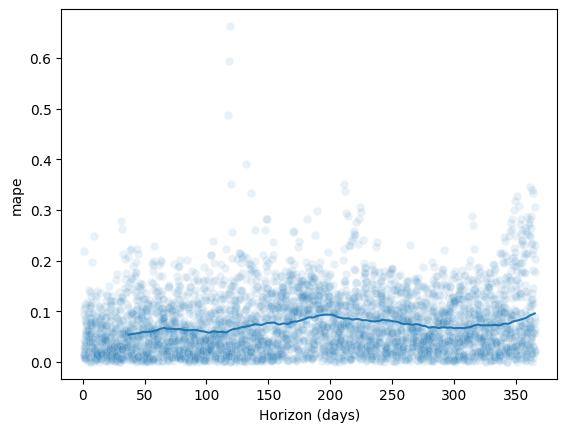

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Same building blocks Prophet uses inside plot_cross_validation_metric
errors = performance_metrics(df_cv, metrics=["mape"], rolling_window=-1)
rolling = performance_metrics(df_cv, metrics=["mape"], rolling_window=0.1)

# Horizon is a Timedelta; convert to days for a plain numeric x-axis
errors = errors.assign(horizon_days=errors["horizon"].dt.total_seconds() / 86_400)
rolling = rolling.assign(horizon_days=rolling["horizon"].dt.total_seconds() / 86_400)

fig, ax = plt.subplots()
sns.scatterplot(
    data=errors,
    x="horizon_days",
    y="mape",
    ax=ax,
    alpha=0.1,
)
sns.lineplot(
    data=rolling,
    x="horizon_days",
    y="mape",
    ax=ax,
)
ax.set(xlabel="Horizon (days)", ylabel="mape");

In the figure:

- Dots show the absolute percent error for each prediction in `df_cv`.
- The blue line shows the MAPE, where the mean is taken over a rolling window of the dots

We see for this forecast that errors around 5% are typical for predictions one month into the future, and that errors increase up to around 11% for predictions that are a year out.

The size of the **rolling window** in the figure can be changed with the optional argument `rolling_window`, which specifies the proportion of forecasts to use in each rolling window. The default is 0.1, corresponding to 10% of rows from `df_cv` included in each window; increasing this will lead to a smoother average curve in the figure.

## Hyperparameter tuning

Cross-validation can be used for tuning hyperparameters of the model. Here we are looking at two of them.

In [ ]:
import itertools

param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(
        model=m,
        initial='730 days',
        period='180 days',
        horizon = '365 days',
        parallel="processes" # Utilizing multi-core processing
    )
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

In [10]:
tuning_results

,changepoint_prior_scale,seasonality_prior_scale,rmse
0,0.001,0.01,0.691759
1,0.001,0.10,0.696795
2,0.001,1.00,0.690848
3,0.001,10.00,0.690050
4,0.010,0.01,0.725074
5,0.010,0.10,0.714926
6,0.010,1.00,0.708763
7,0.010,10.00,0.711607
8,0.100,0.01,0.903396
9,0.100,0.10,0.816426


### Model Parameters for Tuning

Here is the summary of the tunable parameters organized into a quick-reference table:

| **Parameter**                 | **Role / Description**                                    | **Default**  | **Recommended Tuning**                   | **Key Notes**                                                                                                          |
| ----------------------------- | --------------------------------------------------------- | ------------ | ---------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **`changepoint_prior_scale`** | Determines trend flexibility at changepoints.             | `0.05`       | Log scale `[0.001, 0.5]`                 | **Most impactful.** Too small causes underfitting; too large causes overfitting (e.g., treating seasonality as trend). |
| **`seasonality_prior_scale`** | Controls flexibility of seasonal fluctuations.            | `10.0`       | Log scale `[0.01, 10]`                   | Overfitting is rare due to inherent low-pass filtering. Acts as an L2/ridge penalty.                                   |
| **`holidays_prior_scale`**    | Adjusts flexibility to model holiday effects.             | `10.0`       | Range `[0.01, 10]`                       | Minimal regularization needed because holidays typically have multiple historical observations.                        |
| **`seasonality_mode`**        | Dictates how seasonality interacts with the trend.        | `'additive'` | `'additive'` or `'multiplicative'`       | Best tuned visually. Use `'multiplicative'` if seasonal variance grows with the series magnitude.                      |
| **`changepoint_range`**       | Proportion of historical data where the trend can change. | `0.8` (80%)  | `[0.8, 0.95]` (Only in automated setups) | **Usually not tuned.** Prevents overfitting by keeping the trend fixed in the last 20% of the data.                    |

Further reading: [Diagnostics | Prophet Docs](https://facebook.github.io/prophet/docs/diagnostics.html).